# Does the weekly retail-sales pulse tell you when to buy retail stocks? 🛒
### The Redbook same-store-sales index as a shopping-mall crystal ball, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Leads_retail%3F: Not_supported](https://img.shields.io/badge/Leads_retail%3F-Not_supported-8b949e?style=flat-square)

Every Tuesday a research firm publishes the **Johnson Redbook Index** — how much more (or less) America's chain stores rang up this week versus a year ago, measured at the *same stores* so new openings don't flatter it. It's sold as a real-time read on the shopper. The folklore says: when that same-store number **speeds up**, the consumer is getting stronger, so **retail stocks** (the XRT exchange-traded fund) are about to climb — a nowcast you can trade.

It's a tidy story. It's also testable. This notebook asks three blunt questions: when Redbook accelerates, does the retail sector really do better next? Does the sales pulse actually move **first** (that's the whole pitch)? And if you *bought* retail every time Redbook sped up, would you make money?

> 📓 **Plain-language layer.** Want the *t*-stats, the lead/lag cross-correlation, the retail-vs-market test and the synthetic control? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** The weekly Redbook series is **proprietary** (a paid feed, not on FRED), so we use a small, **clearly-labelled approximate reconstruction** of its monthly year-over-year same-store number — the *shape* is faithful to the public record (the 2009 slump into negative growth, the 2018–19 strength, the COVID-2020 collapse, the 2021–22 double-digit reopening/inflation surge), the exact monthly values are approximate. It is a **proxy**, never the licensed tape. XRT is real (yfinance). House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from redbook_retail import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("XRT/SPY cache present:", HAVE_REAL,
      "| Redbook+XRT months:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2006-06-30', 'end': '2026-06-30', 'months': 241, 'years': 20.0, 'h1': (1, 105, 1.04, 1.02, 1.03, 56, 56, 0.01, 0.494), 'h3': (3, 104, 4.01, 2.33, 3.07, 66, 61, 0.63, 0.222), 'h6': (6, 101, 9.13, 4.07, 6.26, 70, 62, 1.21, 0.076), 'h12': (12, 99, 14.07, 12.64, 13.26, 73, 65, 0.24, 0.398), 'rel6': (6, 101, 1.69, 0.31, 0.79, 0.156), 'rel1': (1, 105, -0.39, 0.04, -0.82, 0.819), 'rel12': (12, 99, 0.16, 1.17, -0.4, 0.65), 'leadlag': {-6: 0.067, -5: 0.116, -4: 0.31, -3: 0.328, -2: 0.269, -1: 0.059, 0: 0.018, 1: -0.04, 2: 0.016, 3: 0.046, 4: 0.128, 5: 0.013, 6: -0.111}, 'overlay': (12.05, 0.49, 8.58, 0.52, 8.21, 0.5, 74, 6.06, 4.01), 'reg1': (1, 0.36, 1.63, -1.26, -1.37), 'reg12': (12, 7.82, 17.66, -9.84, -2.28), 'robust': [('k=1', 111, 7.9, 0.72, 0.199), ('k=3', 101, 9.1, 1.21, 0.076), ('k=6', 118, 6.5, 0.12, 0.441), ('smooth3', 122, 7.3, 0.49, 0.279), ('relative', 101, 1.7, 0.79, 0.156), ('ex-COVID', 87, 9.0, 1.22, 0.097)], 'syn': [(0.0, 183, 1.88, 1.5, 0.72, 0.194), (0.05, 183, 6.25, 4.1, 3.66, 0.0)], 'rb_peak': 16.8, 'rb_peak_when': 'Nov 2021', 'rb_trough': -8.4, 'rb_trough_when': 'Apr 2020'}


XRT/SPY cache present: True | Redbook+XRT months: 241


## The answer first

| Question | Answer |
|---|---|
| When Redbook accelerates, does retail do better next? | **Barely, and not reliably.** Over the next 6 months XRT averages **+9.1%** after Redbook speeds up vs **+6.3%** normally — the right direction, but small and **well inside the noise** (you can't tell it from luck). At 1 and 12 months even the direction fades. |
| Does the sales pulse come *first*? | **No — and this is the killer.** Redbook's move lines up best with a retail-stock move that already happened **three months earlier.** The stock market reprices retail *before* the sales gauge confirms it. Redbook *follows*; it doesn't lead. |
| Does it pick retail *over* the market? | **No.** Once you ask whether Redbook predicts retail **beating** the S&P, the tiny edge vanishes (and flips negative at some horizons). |
| So could you trade it? | **It loses.** "Own retail when Redbook accelerates" turned $1 into **$4.0** vs **$6.1** for just holding XRT — you give up return for a nowcast that never shows up. |

> Retail sales and retail stocks obviously move together over the years. But "the weekly sales pulse *warns* you" is a coincident — and inflation-tangled — echo wearing a crystal-ball costume, and acting on it costs you money.

## 1 · The claim

> *"The Redbook Index is the most timely read on the American consumer — weekly, same-store, no lag. When same-store growth accelerates, the shopper is getting stronger, so get long the retail sector before the crowd catches up."*

There's a respectable backbone here: same-store (comparable) sales strip out the noise of new store openings, so a rising Redbook genuinely says *existing* stores are selling more. And retailers live and die on comps. The trading leap is the part we test: that a Redbook *acceleration* arrives early enough, and cleanly enough, to be a **tradable** nowcast for retail *stocks* — not just a number that moves alongside them.

## 2 · So what?

If true, this would be a gift: a public weekly number that tells you when to tilt into the retail sector. But "nowcast" hides two traps. First, the **stock market is itself a forward-looking machine** — XRT reprices the consumer in real time, so a monthly sales gauge may just be *confirming* a move the market already made. Second, Redbook is a **nominal** number: in 2021–22 same-store growth screamed to **double digits** — but that was mostly *inflation*, and XRT actually **fell** through 2022. A gauge that can't tell 'more stuff sold' from 'same stuff, higher prices' is a dangerous thing to buy stocks on. The difference between a *lead* and an *echo* is the difference between an edge and a mirage.

## 3 · How would we even know?

We line up **20 years** (2006–2026, 241 months, XRT's whole life) of the monthly Redbook same-store number against month-end XRT, and:

1. **Split the months.** Call Redbook **accelerating** when same-store growth is above where it was three months ago. Compare what XRT did next (1/3/6/12 months) in accelerating months vs all months.
2. **Check the timing.** The crucial test: slide Redbook forward and backward against the retail sector and find *where* they line up best. If Redbook truly **leads**, the strongest link shows up at a **positive lead** (Redbook first, stocks later).
3. **Try to trade it.** Own XRT whenever Redbook is accelerating, sit in cash otherwise, pay realistic costs — and see if it beats just buying and holding retail.

## 4 · The teardown — let's actually look

**First, the raw material.** Here's the Redbook same-store year-over-year number over two decades — the 2009 dip into *negative* growth, the strong 2018–19 run, the COVID-2020 cliff, and the wild 2021–22 spike to the mid-teens. It clearly *knows* about the consumer. The question is whether it knows **early** — and whether that 2021 spike was strength or just prices.

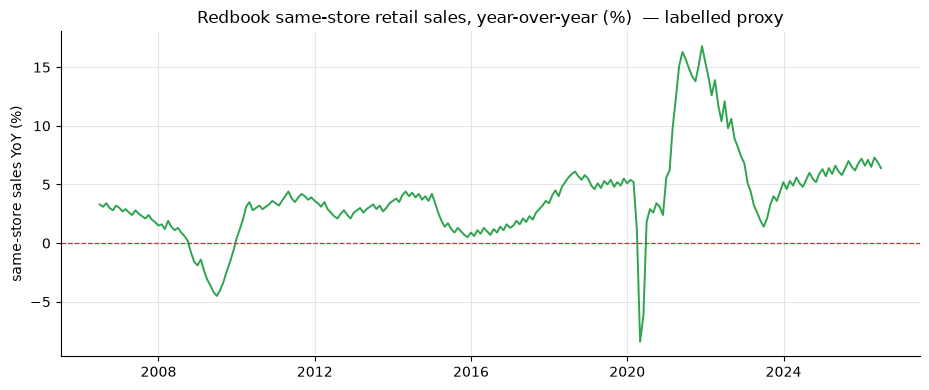

peak 16.8 % around 2021-11-30 | trough -8.4 % around 2020-04-30


In [2]:
if HAVE_REAL:
    y = F['redbook']
    fig, ax = plt.subplots(figsize=(9.4, 4.0))
    ax.plot(y.index, y.values, c=GREEN, lw=1.4)
    ax.axhline(0, c=RED, lw=.9, ls='--')
    ax.set_title('Redbook same-store retail sales, year-over-year (%)  — labelled proxy')
    ax.set_ylabel('same-store sales YoY (%)')
    plt.tight_layout(); plt.show()
    print('peak', y.max(), '% around', y.idxmax().date(), '| trough', y.min(), '% around', y.idxmin().date())
else:
    print('no cache — see docs/results.md; proxy peaked ~+16.8% (Nov 2021), trough -8.4% (Apr 2020)')

**Now the payoff.** For each horizon, the average forward XRT return in **accelerating** months next to the return on an **average** month. The folklore predicts the green bars sit *above* the grey ones.

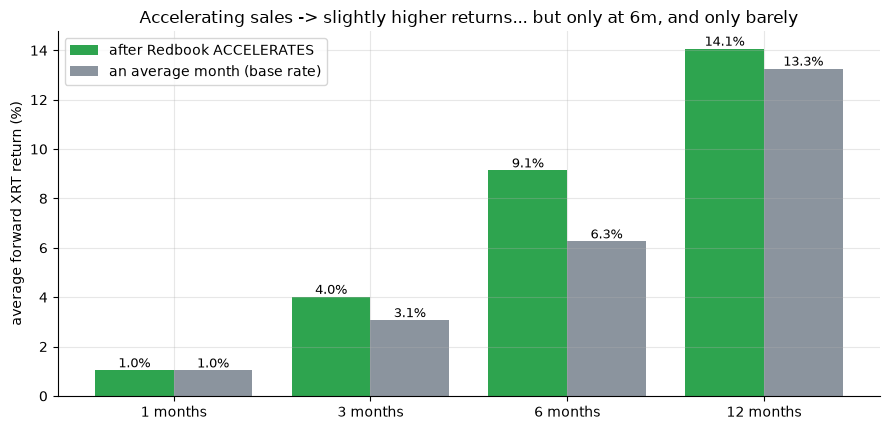

6-month: accel 9.1% vs base 6.3%


In [3]:
hs = [1, 3, 6, 12]
if HAVE_REAL:
    rows = [st.summarize(F, m) for m in hs]
    acc = [r['accel_mean']*100 for r in rows]; base = [r['base_mean']*100 for r in rows]
else:
    acc = [R['h1'][2], R['h3'][2], R['h6'][2], R['h12'][2]]
    base = [R['h1'][4], R['h3'][4], R['h6'][4], R['h12'][4]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(x-.2, acc, .4, color=GREEN, label='after Redbook ACCELERATES')
ax.bar(x+.2, base, .4, color=GREY, label='an average month (base rate)')
ax.set_xticks(x); ax.set_xticklabels([f'{m} months' for m in hs])
ax.set_ylabel('average forward XRT return (%)')
ax.set_title('Accelerating sales -> slightly higher returns... but only at 6m, and only barely')
for i,(a,b) in enumerate(zip(acc,base)):
    ax.annotate(f'{a:.1f}%',(i-.2,a),ha='center',va='bottom',fontsize=9)
    ax.annotate(f'{b:.1f}%',(i+.2,b),ha='center',va='bottom',fontsize=9)
ax.legend(); plt.tight_layout(); plt.show()
print('6-month: accel', f'{acc[2]:.1f}%', 'vs base', f'{base[2]:.1f}%')

At 6 months the accelerating-set return (**+9.1%**) does sit above the base rate (**+6.3%**) — the right direction. But look at 1 month (**+1.0%** vs **+1.0%**, a dead heat) and 12 months (**+14.1%** vs **+13.3%**, almost nothing). The one hopeful bar is small enough that, with the data we have, it could easily be chance. Hold that thought; the *next* chart is where the story breaks.

**The crucial test: does the sales pulse come *first*?** We slide Redbook forward and backward against retail stocks and measure how tightly they move together. A real nowcast would show its strongest *positive* link at a **positive lead** (Redbook leads → bar peaks on the right). Watch where it actually peaks.

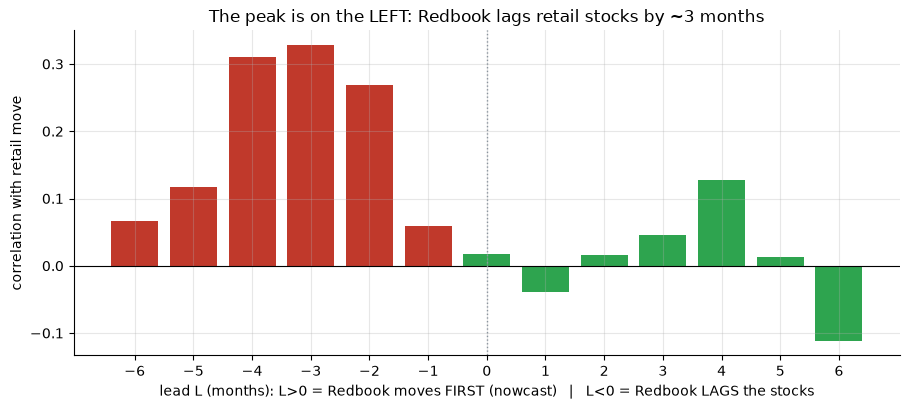

strongest POSITIVE link at L=-3 months (Redbook FOLLOWS the stocks here)


In [4]:
if HAVE_REAL:
    ll = st.lead_lag(F)
    Ls = list(range(-6,7)); cs = [ll[L] for L in Ls]
else:
    Ls = sorted(R['leadlag']); cs = [R['leadlag'][L] for L in Ls]
cols = [RED if L<0 else GREEN for L in Ls]
fig, ax = plt.subplots(figsize=(9.2, 4.2))
ax.bar(Ls, cs, color=cols, width=.8)
ax.axhline(0, c='k', lw=.8); ax.axvline(0, c=GREY, lw=1, ls=':')
ax.set_xlabel('lead L (months): L>0 = Redbook moves FIRST (nowcast)   |   L<0 = Redbook LAGS the stocks')
ax.set_ylabel('correlation with retail move'); ax.set_xticks(Ls)
ax.set_title('The peak is on the LEFT: Redbook lags retail stocks by ~3 months')
plt.tight_layout(); plt.show()
imax = int(np.nanargmax(cs))
print(f'strongest POSITIVE link at L={Ls[imax]} months (Redbook FOLLOWS the stocks here)')

There it is. The tallest *positive* bar is at **L = −3** — the Redbook signal lines up best with a retail-stock move that happened **three months earlier**. On the right, where a true nowcast would live (Redbook moving first), the bars are near zero or even *negative*. **Redbook isn't leading retail stocks — it's trailing them.** The market prices the consumer into XRT first; the same-store sales gauge catches up a quarter later.

**Could you trade it anyway?** Suppose you owned XRT every month Redbook was accelerating and sat in cash otherwise. Here's that strategy's growth vs just buying and holding retail.

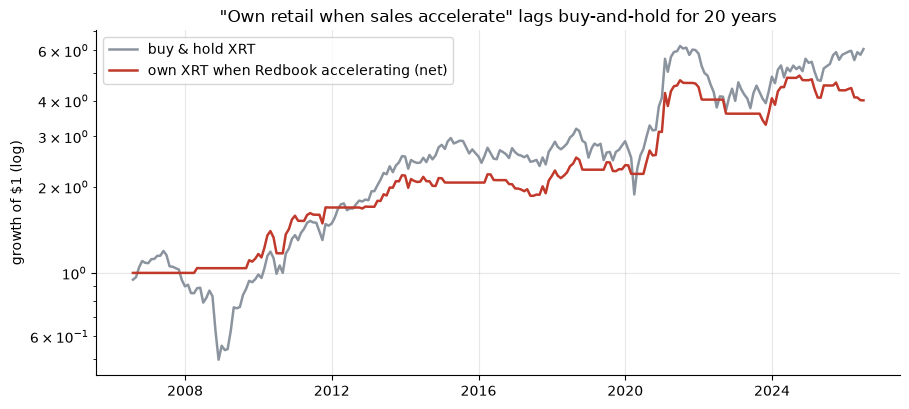

final $1 -> buy&hold 6.1x  vs  overlay 4.0x


In [5]:
if HAVE_REAL:
    accel = st.accel_mask(F); pos = accel.astype(float).shift(1)
    rr = F['xrt'].pct_change()
    import pandas as pd
    dfp = pd.DataFrame({'r': rr, 'pos': pos}).dropna()
    sw = dfp['pos'].diff().abs().fillna(0); c=10/1e4
    overlay = (dfp['pos']*dfp['r'] - sw*c)
    bh_grow = (1+dfp['r']).cumprod(); ov_grow = (1+overlay).cumprod()
    fig, ax = plt.subplots(figsize=(9.2, 4.2))
    ax.plot(bh_grow.index, bh_grow.values, c=GREY, lw=1.8, label='buy & hold XRT')
    ax.plot(ov_grow.index, ov_grow.values, c=RED, lw=1.8, label='own XRT when Redbook accelerating (net)')
    ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)')
    ax.set_title('"Own retail when sales accelerate" lags buy-and-hold for 20 years')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'final $1 -> buy&hold {bh_grow.iloc[-1]:.1f}x  vs  overlay {ov_grow.iloc[-1]:.1f}x')
else:
    print(f"overlay ${R['overlay'][8]:.1f} vs buy-hold ${R['overlay'][7]:.1f} per $1 (net) — see results.md")

The nowcast overlay ends up **below** buy-and-hold — $1 grows to **$4.0** vs **$6.1**, i.e. **+8.2%/yr** net vs **+12.1%/yr**. Because you sit out of the market roughly half the time — including stretches where retail rallies *before* sales confirm — the overlay mostly misses *gains*. It buys you lower volatility (its Sharpe is a near-tie, 0.50 vs 0.49), but no extra reward. There is no free lunch here.

## 5 · The verdict

- **Signal — None.** Accelerating same-store sales are followed by *slightly* better retail returns at one horizon (6 months), but the tilt is small, **not** statistically significant, and it evaporates at 1 and 12 months and once you ask about retail *versus the market*. Indistinguishable from noise.
- **Tradability — Mirage.** Buying retail on Redbook acceleration **loses to buy-and-hold**. There's nothing to deploy.
- **Leads retail? — Not supported.** The Redbook move lines up with a retail-stock move that already happened a quarter earlier. Sales **echo** the sector; they don't forecast it. The one word that makes the pitch — *nowcast* — is the part the data rejects.

## 6 · Could you actually trade it? — the honest bottom line

Forget significance for a second. Even if the small 6-month tilt were real, the operational reality is unkind: Redbook accelerates in **roughly half** of all months (every wiggle of a noisy weekly series counts), so an own-on-acceleration rule whips you in and out constantly — **74 switches** in 20 years — while the *biggest* same-store surges (2021's double digits) were **nominal inflation**, exactly when retail *stocks* were about to fall. A gauge that confuses higher prices with a stronger consumer, and confirms moves the market already made, has nothing left to sell you. There is no version of "buy retail when sales accelerate" that both fires early and makes money.

## 7 · Going further 🚪

- **The sibling tests.** [Study 385 — Jobless-Claims-Momentum](../385-jobless-claims-momentum/) asks the same question of the weekly claims number: real labour signal, but does it *lead* the market or echo it? [Study 384 — ISM-PMI-Regime](../384-ism-pmi-regime/) does it for the manufacturing cycle.
- **Kill the inflation.** Deflate Redbook by CPI to a *real* same-store number — the 2021–22 spike shrinks, and with it the one regime that most confuses the signal. Does a *real* same-store pulse lead any better? (The lead/lag picture barely budges: a coincident series can't be made to lead by re-scaling it.)
- **Build your own.** Swap XRT for individual retailers, or pair Redbook with a price trend filter. If you can show the lead/lag chart peaking on the **right** (positive lead), we'll talk.

*Think the sales pulse leads retail stocks? Show the lead/lag chart peaking on the **right** (Redbook first) — then we'll talk.*